# Comparación robusta de modelos finalistas

Este notebook comprueba si la pequeña ventaja observada para el *stacking* en los notebooks 03 y 04 es estable o depende de una única partición. Compara cuatro finalistas usando exactamente los mismos folds estratificados.

La evaluación evita dos fuentes de optimismo:

- El test original queda reservado y **no se consulta** en ninguna celda de métricas.
- El umbral se aprende en un holdout interno del fold de entrenamiento y se aplica una sola vez al fold externo.

Se ejecutan 5 folds por 2 repeticiones (10 resultados por modelo) y se registran en MLflow tanto los folds como los resúmenes. La comparación principal es pareada: cada candidato se enfrenta al Random Forest de producción sobre las mismas observaciones externas.


In [1]:
import json
import os
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from online_shoppers.data import (
    CATEGORICAL_COLUMNS,
    CONTINUOUS_COLUMNS,
    COUNT_COLUMNS,
    TARGET_COLUMN,
    load_dataset,
)
from online_shoppers.modeling import evaluate_probabilities, select_f1_threshold, split_dataset
from online_shoppers.reporting import write_json

sns.set_theme(style="whitegrid")

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
DATA_PATH = ROOT / "data/raw/online_shoppers_intention.csv"
REPORTS_DIR = ROOT / "reports/experiments"
FIGURES_DIR = ROOT / "notebooks/reports/figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", f"sqlite:///{ROOT / 'mlflow.db'}")
EXPERIMENT_NAME = "online-shoppers-robust-comparison"
RANDOM_SEED = 42
N_SPLITS = 5
N_REPEATS = 2
THRESHOLD_HOLDOUT_SIZE = 0.20
RUN_GROUP = datetime.now(UTC).strftime("%Y%m%dT%H%M%SZ")

sessions = load_dataset(DATA_PATH)
original_splits = split_dataset(sessions, random_seed=RANDOM_SEED)
development = pd.concat([original_splits.train, original_splits.validation], ignore_index=True)
X_development = development.drop(columns=TARGET_COLUMN)
y_development = development[TARGET_COLUMN].astype(bool)

{
    "development_rows": len(development),
    "reserved_test_rows": len(original_splits.test),
    "outer_evaluations_per_model": N_SPLITS * N_REPEATS,
    "test_used_for_metrics": False,
}


/Users/mijo/Documents/Maestria/2026-4/Semana 3/maia_despliegue_soluciones_microproyecto/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'development_rows': 9864,
 'reserved_test_rows': 2466,
 'outer_evaluations_per_model': 10,
 'test_used_for_metrics': False}

## Feature engineering dentro de cada fold

Las variables derivadas coinciden con `03_model_experiments.ipynb`, pero el conjunto de códigos frecuentes de `TrafficType` se aprende dentro de cada entrenamiento. De esta manera ni el fold externo ni el test influyen en la transformación.


In [2]:
BASE_NUMERIC = [*COUNT_COLUMNS, *CONTINUOUS_COLUMNS]
BASE_CATEGORICAL = list(CATEGORICAL_COLUMNS)
ENGINEERED_NUMERIC = [
    "total_duration",
    "total_pageviews",
    "avg_duration_per_page",
    "admin_duration_share",
    "product_duration_share",
    "bounce_exit_gap",
    "engagement_score",
    "page_values_log",
    "product_related_duration_log",
    "has_special_day",
]
ENGINEERED_CATEGORICAL = ["month_quarter", "traffic_type_grouped", "is_weekend_returning"]
FULL_NUMERIC = BASE_NUMERIC + ENGINEERED_NUMERIC
FULL_CATEGORICAL = BASE_CATEGORICAL + ENGINEERED_CATEGORICAL


class SessionFeatureEngineer(BaseEstimator, TransformerMixin):
    """Learn fold-local traffic buckets and add leakage-free row features."""

    def __init__(self, min_traffic_frequency=200):
        self.min_traffic_frequency = min_traffic_frequency

    def fit(self, X, y=None):
        counts = X["TrafficType"].value_counts()
        self.frequent_traffic_types_ = set(
            counts[counts >= self.min_traffic_frequency].index
        )
        return self

    def transform(self, X):
        engineered = X.copy()
        total_duration = (
            engineered["Administrative_Duration"]
            + engineered["Informational_Duration"]
            + engineered["ProductRelated_Duration"]
        )
        total_pageviews = (
            engineered["Administrative"]
            + engineered["Informational"]
            + engineered["ProductRelated"]
        )
        engineered["total_duration"] = total_duration
        engineered["total_pageviews"] = total_pageviews
        engineered["avg_duration_per_page"] = (
            (total_duration / total_pageviews).replace([np.inf, -np.inf], 0).fillna(0)
        )
        engineered["admin_duration_share"] = (
            (engineered["Administrative_Duration"] / total_duration)
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
        )
        engineered["product_duration_share"] = (
            (engineered["ProductRelated_Duration"] / total_duration)
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
        )
        engineered["bounce_exit_gap"] = engineered["ExitRates"] - engineered["BounceRates"]
        engineered["engagement_score"] = engineered["ProductRelated_Duration"] * (
            1 - engineered["ExitRates"]
        )
        engineered["page_values_log"] = np.log1p(engineered["PageValues"])
        engineered["product_related_duration_log"] = np.log1p(
            engineered["ProductRelated_Duration"]
        )
        engineered["has_special_day"] = (engineered["SpecialDay"] > 0).astype(int)
        engineered["month_quarter"] = np.where(
            engineered["Month"].isin(["Nov", "Dec"]), "holiday_peak", "regular"
        )
        engineered["traffic_type_grouped"] = (
            engineered["TrafficType"]
            .where(engineered["TrafficType"].isin(self.frequent_traffic_types_), other=-1)
            .astype(str)
        )
        engineered["is_weekend_returning"] = (
            engineered["Weekend"]
            & (engineered["VisitorType"] == "Returning_Visitor")
        ).astype(str)
        return engineered


class DataFrameSelector(BaseEstimator, TransformerMixin):
    """Keep CatBoost columns ordered and categorical values string-typed."""

    def __init__(self, numeric_columns, categorical_columns):
        self.numeric_columns = numeric_columns
        self.categorical_columns = categorical_columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        selected = X.loc[:, [*self.numeric_columns, *self.categorical_columns]].copy()
        for column in self.categorical_columns:
            selected[column] = selected[column].astype(str)
        return selected


## Candidatos

El Random Forest conserva las variables y parámetros del champion de producción. Los otros tres candidatos utilizan `engineered_full`. CatBoost usa la mejor configuración focal por F1 de la ronda 2 (`alpha=0.25`, `gamma=2`). En esta comparación se fija en 500 iteraciones sin *early stopping*: ningún fold externo puede intervenir en la duración del entrenamiento.


In [3]:
def build_preprocessor(numeric_columns, categorical_columns):
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([("scale", StandardScaler())]), numeric_columns),
            (
                "categorical",
                Pipeline(
                    [("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]
                ),
                categorical_columns,
            ),
        ],
        remainder="drop",
    )


def build_sklearn_pipeline(estimator, numeric_columns, categorical_columns):
    return Pipeline(
        [
            ("engineer", SessionFeatureEngineer()),
            ("preprocess", build_preprocessor(numeric_columns, categorical_columns)),
            ("classifier", estimator),
        ]
    )


def build_random_forest(seed):
    return build_sklearn_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=1,
            random_state=seed,
        ),
        BASE_NUMERIC,
        BASE_CATEGORICAL,
    )


def build_hist_gradient_boosting(seed):
    return build_sklearn_pipeline(
        HistGradientBoostingClassifier(class_weight="balanced", random_state=seed),
        FULL_NUMERIC,
        FULL_CATEGORICAL,
    )


def build_stacking(seed):
    estimator = StackingClassifier(
        estimators=[
            (
                "random_forest",
                RandomForestClassifier(
                    n_estimators=300,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    n_jobs=1,
                    random_state=seed,
                ),
            ),
            (
                "extra_trees",
                ExtraTreesClassifier(
                    n_estimators=300,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    n_jobs=1,
                    random_state=seed,
                ),
            ),
            (
                "hist_gradient_boosting",
                HistGradientBoostingClassifier(class_weight="balanced", random_state=seed),
            ),
        ],
        final_estimator=LogisticRegression(max_iter=2000, random_state=seed),
        stack_method="predict_proba",
        n_jobs=1,
    )
    return build_sklearn_pipeline(estimator, FULL_NUMERIC, FULL_CATEGORICAL)


def build_catboost_focal(seed):
    categorical_indices = list(range(len(FULL_NUMERIC), len(FULL_NUMERIC) + len(FULL_CATEGORICAL)))
    return Pipeline(
        [
            ("engineer", SessionFeatureEngineer()),
            ("select", DataFrameSelector(FULL_NUMERIC, FULL_CATEGORICAL)),
            (
                "classifier",
                CatBoostClassifier(
                    cat_features=categorical_indices,
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    loss_function="Focal:focal_alpha=0.25;focal_gamma=2.0",
                    eval_metric="F1",
                    random_seed=seed,
                    verbose=False,
                    allow_writing_files=False,
                    thread_count=-1,
                ),
            ),
        ]
    )


MODEL_SPECS = {
    "random_forest_production": {
        "builder": build_random_forest,
        "feature_set": "base_with_page_values",
        "configuration": "n_estimators=300,min_samples_leaf=2,class_weight=balanced",
    },
    "hist_gradient_boosting": {
        "builder": build_hist_gradient_boosting,
        "feature_set": "engineered_full",
        "configuration": "class_weight=balanced,sklearn_defaults",
    },
    "stacking_trees": {
        "builder": build_stacking,
        "feature_set": "engineered_full",
        "configuration": "random_forest+extra_trees+hist_gradient_boosting,logistic_meta",
    },
    "catboost_focal": {
        "builder": build_catboost_focal,
        "feature_set": "engineered_full",
        "configuration": "iterations=500,depth=6,learning_rate=0.05,alpha=0.25,gamma=2",
    },
}
list(MODEL_SPECS)


['random_forest_production',
 'hist_gradient_boosting',
 'stacking_trees',
 'catboost_focal']

## Evaluación repetida y registro

Para cada fold externo, el 20 % del entrenamiento externo se reserva temporalmente para escoger el umbral. Después se crea un modelo nuevo, se ajusta con todo el entrenamiento externo y se evalúa con ese umbral sobre el fold externo intacto.


In [4]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_SEED
)
outer_partitions = list(outer_cv.split(X_development, y_development))
results = []

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

for model_name, spec in MODEL_SPECS.items():
    with mlflow.start_run(run_name=f"{RUN_GROUP}__{model_name}__summary"):
        mlflow.set_tags(
            {
                "run_group": RUN_GROUP,
                "run_type": "model_summary",
                "uses_test_set": "false",
            }
        )
        mlflow.log_params(
            {
                "model": model_name,
                "feature_set": spec["feature_set"],
                "configuration": spec["configuration"],
                "outer_splits": N_SPLITS,
                "outer_repeats": N_REPEATS,
                "threshold_holdout_size": THRESHOLD_HOLDOUT_SIZE,
                "random_seed": RANDOM_SEED,
                "selection_metric": "f1",
            }
        )

        model_rows = []
        for split_index, (outer_train_idx, outer_eval_idx) in enumerate(outer_partitions):
            repeat = split_index // N_SPLITS + 1
            fold = split_index % N_SPLITS + 1
            fold_seed = RANDOM_SEED + split_index

            X_outer_train = X_development.iloc[outer_train_idx]
            y_outer_train = y_development.iloc[outer_train_idx]
            X_outer_eval = X_development.iloc[outer_eval_idx]
            y_outer_eval = y_development.iloc[outer_eval_idx]

            X_fit, X_threshold, y_fit, y_threshold = train_test_split(
                X_outer_train,
                y_outer_train,
                test_size=THRESHOLD_HOLDOUT_SIZE,
                random_state=fold_seed,
                stratify=y_outer_train,
            )

            threshold_model = spec["builder"](fold_seed)
            threshold_model.fit(X_fit, y_fit)
            threshold_probabilities = threshold_model.predict_proba(X_threshold)[:, 1]
            threshold = select_f1_threshold(
                y_threshold.to_numpy(), threshold_probabilities
            )

            evaluation_model = spec["builder"](fold_seed)
            evaluation_model.fit(X_outer_train, y_outer_train)
            evaluation_probabilities = evaluation_model.predict_proba(X_outer_eval)[:, 1]
            metrics = evaluate_probabilities(y_outer_eval, evaluation_probabilities, threshold)
            row = {
                "model": model_name,
                "feature_set": spec["feature_set"],
                "repeat": repeat,
                "fold": fold,
                "fold_seed": fold_seed,
                "threshold": threshold,
                **metrics,
            }
            results.append(row)
            model_rows.append(row)

            with mlflow.start_run(
                run_name=f"{model_name}__repeat_{repeat}__fold_{fold}", nested=True
            ):
                mlflow.set_tags(
                    {
                        "run_group": RUN_GROUP,
                        "run_type": "outer_fold",
                        "uses_test_set": "false",
                    }
                )
                mlflow.log_params(
                    {
                        "model": model_name,
                        "feature_set": spec["feature_set"],
                        "configuration": spec["configuration"],
                        "repeat": repeat,
                        "fold": fold,
                        "fold_seed": fold_seed,
                        "threshold_source": "inner_holdout",
                    }
                )
                mlflow.log_metric("threshold", threshold)
                mlflow.log_metrics(
                    {f"outer_{key}": float(value) for key, value in metrics.items()}
                )

        model_frame = pd.DataFrame(model_rows)
        for metric_name in ("f1", "pr_auc", "roc_auc", "brier_score", "threshold"):
            mlflow.log_metric(f"mean_{metric_name}", float(model_frame[metric_name].mean()))
            mlflow.log_metric(f"std_{metric_name}", float(model_frame[metric_name].std(ddof=1)))

results_df = pd.DataFrame(results)
results_df.shape


2026/08/21 21:08:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/21 21:08:58 INFO mlflow.store.db.utils: Updating database tables


2026/08/21 21:08:58 INFO mlflow.tracking.fluent: Experiment with name 'online-shoppers-robust-comparison' does not exist. Creating a new experiment.


(40, 16)

## Resumen y comparación pareada

Los intervalos son percentiles empíricos de los diez folds. La evidencia de mejora exige que el intervalo de las diferencias pareadas de F1 quede completamente por encima de cero; esto evita declarar ganador por una diferencia promedio frágil.


In [5]:
SUMMARY_METRICS = ["f1", "pr_auc", "roc_auc", "precision", "recall", "brier_score", "threshold"]
summary_rows = []
for model_name, group in results_df.groupby("model", sort=False):
    row = {"model": model_name, "feature_set": group["feature_set"].iloc[0]}
    for metric_name in SUMMARY_METRICS:
        values = group[metric_name].astype(float)
        row[f"{metric_name}_mean"] = float(values.mean())
        row[f"{metric_name}_std"] = float(values.std(ddof=1))
        row[f"{metric_name}_ci_low"] = float(values.quantile(0.025))
        row[f"{metric_name}_ci_high"] = float(values.quantile(0.975))
    summary_rows.append(row)

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("f1_mean", ascending=False)
    .reset_index(drop=True)
)

fold_keys = ["repeat", "fold"]
f1_wide = results_df.pivot(index=fold_keys, columns="model", values="f1")
baseline_name = "random_forest_production"
paired_rows = []
paired_long_rows = []
for model_name in MODEL_SPECS:
    deltas = f1_wide[model_name] - f1_wide[baseline_name]
    for (repeat, fold), delta in deltas.items():
        paired_long_rows.append(
            {"model": model_name, "repeat": repeat, "fold": fold, "delta_f1": float(delta)}
        )
    paired_rows.append(
        {
            "model": model_name,
            "mean_delta_f1_vs_random_forest": float(deltas.mean()),
            "delta_ci_low": float(deltas.quantile(0.025)),
            "delta_ci_high": float(deltas.quantile(0.975)),
            "fold_win_rate": float((deltas > 0).mean()),
            "evidence_of_improvement": bool(deltas.quantile(0.025) > 0),
        }
    )
paired_df = pd.DataFrame(paired_rows).sort_values(
    "mean_delta_f1_vs_random_forest", ascending=False
).reset_index(drop=True)
paired_long_df = pd.DataFrame(paired_long_rows)

display(
    summary_df[
        [
            "model",
            "f1_mean",
            "f1_std",
            "f1_ci_low",
            "f1_ci_high",
            "pr_auc_mean",
            "roc_auc_mean",
            "brier_score_mean",
            "threshold_mean",
        ]
    ]
)
display(paired_df)


,model,f1_mean,f1_std,f1_ci_low,f1_ci_high,pr_auc_mean,roc_auc_mean,brier_score_mean,threshold_mean
0,catboost_focal,0.682340,0.017074,0.656314,0.704427,0.753194,0.933388,0.082337,0.329239
1,random_forest_production,0.676965,0.020915,0.652781,0.716078,0.733655,0.929014,0.085706,0.537538
2,stacking_trees,0.675197,0.014388,0.649854,0.694723,0.745116,0.931758,0.070073,0.293163
3,hist_gradient_boosting,0.672726,0.018685,0.643227,0.703050,0.744220,0.931019,0.085463,0.647799


,model,mean_delta_f1_vs_random_forest,delta_ci_low,delta_ci_high,fold_win_rate,evidence_of_improvement
0,catboost_focal,0.005375,-0.016180,0.018898,0.7,False
1,random_forest_production,0.000000,0.000000,0.000000,0.0,False
2,stacking_trees,-0.001768,-0.023872,0.013958,0.5,False
3,hist_gradient_boosting,-0.004238,-0.049829,0.023872,0.6,False


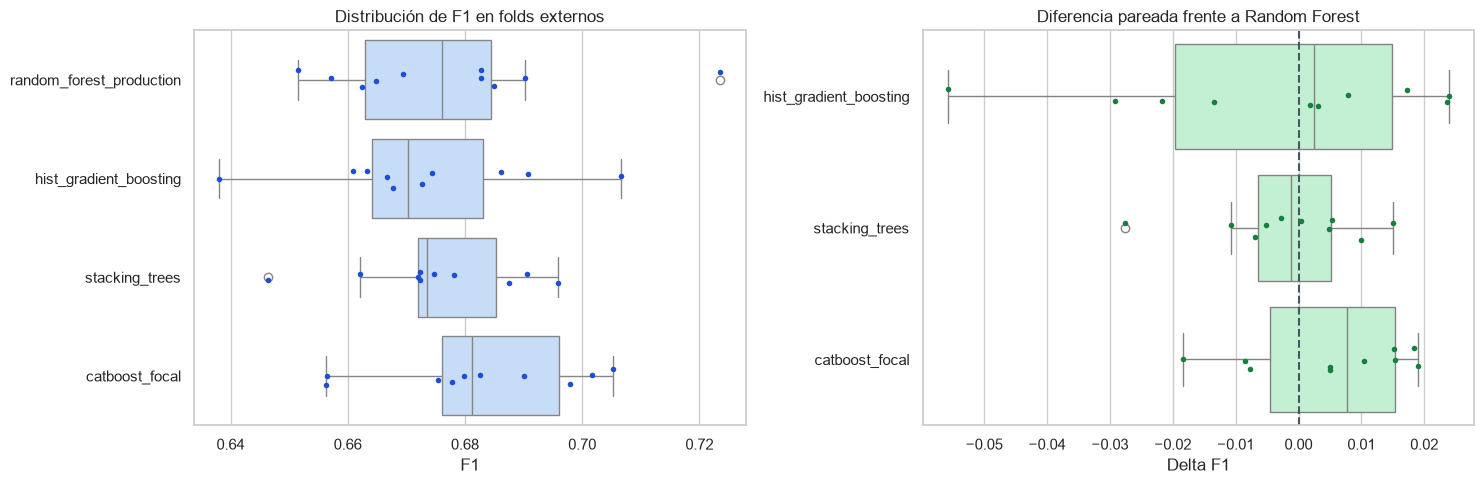

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=results_df, x="f1", y="model", ax=axes[0], color="#bfdbfe")
sns.stripplot(data=results_df, x="f1", y="model", ax=axes[0], color="#1d4ed8", size=4)
axes[0].set(title="Distribución de F1 en folds externos", xlabel="F1", ylabel="")

non_baseline_deltas = paired_long_df[paired_long_df["model"] != baseline_name]
sns.boxplot(
    data=non_baseline_deltas, x="delta_f1", y="model", ax=axes[1], color="#bbf7d0"
)
sns.stripplot(
    data=non_baseline_deltas, x="delta_f1", y="model", ax=axes[1], color="#15803d", size=4
)
axes[1].axvline(0, color="#475569", linestyle="--")
axes[1].set(
    title="Diferencia pareada frente a Random Forest",
    xlabel="Delta F1",
    ylabel="",
)
fig.tight_layout()
figure_path = FIGURES_DIR / "robust_model_comparison.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()


## Persistencia y recomendación

Se guardan los resultados por fold, el resumen y las diferencias pareadas. La recomendación identifica el mayor F1 promedio, pero solo propone reemplazar el baseline cuando la evidencia pareada es positiva en todo el intervalo empírico. Este notebook no modifica artefactos de producción.


In [7]:
folds_path = REPORTS_DIR / "robust_model_comparison_folds.csv"
summary_path = REPORTS_DIR / "robust_model_comparison.json"
results_df.to_csv(folds_path, index=False)

best_model = str(summary_df.iloc[0]["model"])
best_paired = paired_df.set_index("model").loc[best_model]
recommend_promotion = bool(
    best_model != baseline_name and best_paired["evidence_of_improvement"]
)
payload = {
    "run_group": RUN_GROUP,
    "experiment_name": EXPERIMENT_NAME,
    "evaluation": {
        "outer_splits": N_SPLITS,
        "outer_repeats": N_REPEATS,
        "threshold_holdout_size": THRESHOLD_HOLDOUT_SIZE,
        "development_rows": len(development),
        "reserved_test_rows": len(original_splits.test),
        "test_used_for_metrics": False,
    },
    "models": json.loads(summary_df.to_json(orient="records")),
    "paired_comparison": json.loads(paired_df.to_json(orient="records")),
    "decision": {
        "best_mean_f1_model": best_model,
        "baseline_model": baseline_name,
        "recommend_promotion": recommend_promotion,
        "rule": "promote only when the empirical 95% interval of paired F1 deltas is above zero",
    },
}
write_json(summary_path, payload)

with mlflow.start_run(run_name=f"{RUN_GROUP}__global_summary"):
    mlflow.set_tags(
        {
            "run_group": RUN_GROUP,
            "run_type": "global_summary",
            "uses_test_set": "false",
        }
    )
    mlflow.log_params(
        {
            "best_mean_f1_model": best_model,
            "baseline_model": baseline_name,
            "recommend_promotion": recommend_promotion,
            "candidate_count": len(MODEL_SPECS),
            "outer_evaluations_per_model": N_SPLITS * N_REPEATS,
        }
    )
    for _, row in summary_df.iterrows():
        safe_name = str(row["model"])
        mlflow.log_metric(f"{safe_name}_mean_f1", float(row["f1_mean"]))
        mlflow.log_metric(f"{safe_name}_mean_pr_auc", float(row["pr_auc_mean"]))
    mlflow.log_artifact(str(folds_path))
    mlflow.log_artifact(str(summary_path))
    mlflow.log_artifact(str(figure_path))

payload["decision"]


{'best_mean_f1_model': 'catboost_focal',
 'baseline_model': 'random_forest_production',
 'recommend_promotion': False,
 'rule': 'promote only when the empirical 95% interval of paired F1 deltas is above zero'}

## Lectura del resultado

- Si `recommend_promotion` es `false`, la evidencia disponible no justifica reemplazar el Random Forest, aunque otro modelo tenga un promedio ligeramente mayor.
- Si es `true`, todavía debe ejecutarse el flujo controlado de promoción en una etapa separada.
- El test reservado no debe abrirse desde este notebook.
- Los resultados pueden inspeccionarse con `uv run mlflow ui --backend-store-uri sqlite:///mlflow.db` en el experimento `online-shoppers-robust-comparison`.
